In [1]:
import os
import random
import shutil
import numpy as np
from glob import glob
from collections import defaultdict
from typing import List, Tuple
 
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms.v2 as transforms
import torchvision.tv_tensors as tv_tensors
from tqdm import tqdm
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
 
# paths
IMAGES_ROOT = "../data/20_trees/Images"
GT_ROOT     = "../data/20_trees/Ground_truths"
OUT_DIR     = "../logs/20_trees"
CACHE_DIR   = "./cache"
os.makedirs(os.path.join(OUT_DIR, "checkpoints"), exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)
 
# class mapping
# Raw mask pixel values: 1=Background 2=Bark 3=Wood 4=Knot 5=Crack
# Remapped to 0-based for loss functions
CLASS_REMAP            = {1: 0, 2: 1, 3: 2, 4: 3, 5: 4}
CLASS_NAMES            = ["Background", "Bark", "Wood", "Knot", "Crack"]
CLASS_COLORS           = {0: "#4A5568", 1: "#8D6E63", 2: "#D4A96A", 3: "#FF6F00", 4: "#E53935"}
NUM_CLASSES            = 5
DEFECT_CLASSES         = [3, 4]   # remapped indices for Knot and Crack
DEFECT_RAW_VALUES      = [4, 5]   # raw mask values used for defect presence check
 
# training config
PATCH_SIZE          = 256
BATCH_SIZE          = 8
EPOCHS              = 200
LR                  = 1e-3
EARLY_STOP          = 15
REPEAT              = 5
DEFECT_SAMPLE_RATIO = 0.75
SEED                = 42
 
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
PREFIX_OVERRIDE = {}
 
def mask_stem_to_image_stem(mask_filename):
    name  = os.path.splitext(mask_filename)[0]
    parts = name.split("_", 2)
    stem  = parts[2] if len(parts) == 3 else name
    for wrong, correct in PREFIX_OVERRIDE.items():
        if stem.startswith(wrong):
            stem = correct + stem[len(wrong):]
            break
    return stem
 
image_paths  = sorted(glob(os.path.join(IMAGES_ROOT, "**", "*.tif"), recursive=True))
mask_paths   = sorted(glob(
    os.path.join(GT_ROOT, "**", "GroundTruthProject", "PixelLabelData", "*.png"),
    recursive=True
))
image_lookup = {os.path.splitext(os.path.basename(p))[0]: p for p in image_paths}
 
all_pairs = []
for mp in mask_paths:
    stem = mask_stem_to_image_stem(os.path.basename(mp))
    if stem in image_lookup:
        all_pairs.append((image_lookup[stem], mp))
 
print(f"Total matched pairs: {len(all_pairs)}")

Total matched pairs: 1347


In [3]:
# EDA: Dub 3 + kmen7 (heaviest) in train
#       Val:  one mixed log per batch  (Dub 4, kmen6)
#       Test: knot-dominant + crack-dominant (Dub 9, kmen9)
#       Near-zero logs (Dub 10, kmen1, kmen10) in train as hard negatives
def get_log_id(img_path):
    parts     = img_path.replace("\\", "/").split("/")
    log_names = set(os.listdir(IMAGES_ROOT))
    return next((p for p in parts if p in log_names), None)
 
log_pairs = defaultdict(list)
for pair in all_pairs:
    log_id = get_log_id(pair[0])
    if log_id:
        log_pairs[log_id].append(pair)
 
all_logs   = sorted(log_pairs.keys())
VAL_LOGS   = ["Dub 4", "kmen6"]
TEST_LOGS  = ["Dub 9", "kmen9"]
TRAIN_LOGS = [l for l in all_logs if l not in VAL_LOGS + TEST_LOGS]
 
train_pairs = [p for lg in TRAIN_LOGS for p in log_pairs[lg]]
val_pairs   = [p for lg in VAL_LOGS   for p in log_pairs[lg]]
test_pairs  = [p for lg in TEST_LOGS  for p in log_pairs[lg]]
 
print(f"All logs   : {all_logs}")
print(f"Train logs : {TRAIN_LOGS}")
print(f"Val logs   : {VAL_LOGS}")
print(f"Test logs  : {TEST_LOGS}")
print(f"Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}")

All logs   : ['Dub 1', 'Dub 10', 'Dub 2', 'Dub 3', 'Dub 4', 'Dub 5', 'Dub 6', 'Dub 7', 'Dub 8', 'Dub 9', 'kmen1', 'kmen10', 'kmen2', 'kmen3', 'kmen4', 'kmen5', 'kmen6', 'kmen7', 'kmen8', 'kmen9']
Train logs : ['Dub 1', 'Dub 10', 'Dub 2', 'Dub 3', 'Dub 5', 'Dub 6', 'Dub 7', 'Dub 8', 'kmen1', 'kmen10', 'kmen2', 'kmen3', 'kmen4', 'kmen5', 'kmen7', 'kmen8']
Val logs   : ['Dub 4', 'kmen6']
Test logs  : ['Dub 9', 'kmen9']
Train: 1090 | Val: 129 | Test: 128


In [4]:
def crop_to_foreground(img, mask, margin=10):
    """Tight crop around non-background mask region. From preprocess.py."""
    coords = np.column_stack(np.where(mask > 0))
    if coords.size == 0:
        return img, mask
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    y_min = max(y_min - margin, 0)
    x_min = max(x_min - margin, 0)
    y_max = min(y_max + margin, img.shape[0])
    x_max = min(x_max + margin, img.shape[1])
    return img[y_min:y_max, x_min:x_max], mask[y_min:y_max, x_min:x_max]
 
 
def remap_mask(mask):
    """Map raw pixel values (1-5) to 0-based class indices."""
    out = np.zeros_like(mask, dtype=np.int64)
    for raw, idx in CLASS_REMAP.items():
        out[mask == raw] = idx
    return out
 
 
def load_and_preprocess(img_path, mask_path):
    """
    Load pair, align sizes, crop, resize, normalise per-image, remap mask.
    Returns plain numpy arrays — no tensors, no tv_tensors.
    """
    img  = cv2.imread(img_path,  cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
 
    if img is None:
        raise FileNotFoundError(f"Cannot read: {img_path}")
    if mask is None:
        raise FileNotFoundError(f"Cannot read: {mask_path}")
 
    # EDA: align sizes before anything else
    if mask.shape[:2] != img.shape[:2]:
        mask = cv2.resize(mask, (img.shape[1], img.shape[0]),
                          interpolation=cv2.INTER_NEAREST)
 
    img, mask = crop_to_foreground(img, mask)
 
    img  = cv2.resize(img,  (PATCH_SIZE, PATCH_SIZE), interpolation=cv2.INTER_AREA)
    mask = cv2.resize(mask, (PATCH_SIZE, PATCH_SIZE), interpolation=cv2.INTER_NEAREST)
 
    # EDA: per-image normalisation handles Kmen/Dub brightness gap
    img = img.astype(np.float32)
    img = (img - img.mean()) / (img.std() + 1e-6)
    img = np.expand_dims(img, axis=0)   # (1, H, W)
 
    mask = remap_mask(mask)             # (H, W) int64
 
    # guarantee plain numeric arrays — prevents pickle in np.save
    return np.array(img, dtype=np.float32), np.array(mask, dtype=np.int64)

In [5]:
def build_cache(pairs, cache_dir, force=False):
    """
    Preprocess all pairs and save as .npy files.
    Returns list of (img_npy_path, mask_npy_path) tuples.
    """
    if force and os.path.exists(cache_dir):
        shutil.rmtree(cache_dir)
        print(f"Cleared existing cache: {cache_dir}")
    os.makedirs(cache_dir, exist_ok=True)
 
    cached = []
    for img_path, mask_path in tqdm(pairs, desc=f"Caching → {cache_dir}"):
        stem      = os.path.splitext(os.path.basename(img_path))[0]
        img_file  = os.path.join(cache_dir, stem + "_img.npy")
        mask_file = os.path.join(cache_dir, stem + "_mask.npy")
 
        if not os.path.exists(img_file):
            img, mask = load_and_preprocess(img_path, mask_path)
            np.save(img_file,  img)
            np.save(mask_file, mask)
 
        cached.append((img_file, mask_file))
 
    # verify first entry loads correctly
    test_img  = np.load(cached[0][0])
    test_mask = np.load(cached[0][1])
    print(f"  Cache OK — img: {test_img.shape} {test_img.dtype} "
          f"| mask: {test_mask.shape} {test_mask.dtype} "
          f"| unique mask values: {np.unique(test_mask).tolist()}")
    return cached
 
 
# set force=True to rebuild from scratch, False to reuse existing files
cached_train = build_cache(train_pairs, os.path.join(CACHE_DIR, "train"), force=False)
cached_val   = build_cache(val_pairs,   os.path.join(CACHE_DIR, "val"),   force=False)
cached_test  = build_cache(test_pairs,  os.path.join(CACHE_DIR, "test"),  force=False)
 
print(f"\nCached — Train: {len(cached_train)} | Val: {len(cached_val)} | Test: {len(cached_test)}")

Caching → ./cache\train: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1090/1090 [00:00<00:00, 12208.27it/s]


  Cache OK — img: (1, 256, 256) float32 | mask: (256, 256) int64 | unique mask values: [0, 1, 2, 3, 4]


Caching → ./cache\val: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 129/129 [00:00<00:00, 16124.25it/s]


  Cache OK — img: (1, 256, 256) float32 | mask: (256, 256) int64 | unique mask values: [0, 1, 2, 3, 4]


Caching → ./cache\test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [00:00<00:00, 18174.99it/s]

  Cache OK — img: (1, 256, 256) float32 | mask: (256, 256) int64 | unique mask values: [0, 1, 2, 3, 4]

Cached — Train: 1090 | Val: 129 | Test: 128


In [6]:
class WoodValDataset(Dataset):
    """Val / test — loads from cache, no augmentation."""
    def __init__(self, cached_pairs: List[Tuple[str, str]]):
        self.pairs = cached_pairs
 
    def __len__(self):
        return len(self.pairs)
 
    def __getitem__(self, idx):
        img  = np.load(self.pairs[idx][0])
        mask = np.load(self.pairs[idx][1])
        return (torch.tensor(img,  dtype=torch.float32),
                torch.tensor(mask, dtype=torch.long))
 
 
class WoodTrainDataset(Dataset):
    """
    Train — loads from cache, applies augmentation on repeats 1..N.
    Repeat 0 = clean copy, preserves one unaugmented version per image.
    Mirrors WoodAugmentedDataset from old datamodule.py.
    """
    def __init__(self, cached_pairs: List[Tuple[str, str]], repeat: int = REPEAT):
        self.pairs   = list(cached_pairs)
        self.repeat  = repeat
        self.transform = transforms.Compose([
            transforms.RandomRotation(degrees=(-180, 180)),   # EDA: essential
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
        ])
 
    def __len__(self):
        return len(self.pairs) * self.repeat
 
    def __getitem__(self, idx):
        base_idx   = idx % len(self.pairs)
        repeat_idx = idx // len(self.pairs)
 
        img  = np.load(self.pairs[base_idx][0])
        mask = np.load(self.pairs[base_idx][1])
 
        img_t  = tv_tensors.Image(torch.tensor(img,  dtype=torch.float32))
        mask_t = tv_tensors.Mask(torch.tensor(mask, dtype=torch.long))
 
        if repeat_idx > 0:
            img_t, mask_t = self.transform(img_t, mask_t)
 
        return img_t, mask_t
 

In [7]:
# EDA: 20% images have zero defects - guarantee DEFECT_SAMPLE_RATIO
# of each batch comes from defect-positive images
def make_defect_aware_sampler(cached_pairs, repeat):
    print("Building defect-aware sampler...")
    flags = []
    for _, mask_npy in tqdm(cached_pairs):
        mask = np.load(mask_npy)
        # DEFECT_CLASSES are remapped indices (3=Knot, 4=Crack)
        flags.append(bool(np.any(np.isin(mask, DEFECT_CLASSES))))
 
    all_flags = flags * repeat
    n_def     = sum(all_flags) + 1e-9
    n_clean   = len(all_flags) - n_def + 1e-9
    w_def     = DEFECT_SAMPLE_RATIO / n_def
    w_clean   = (1 - DEFECT_SAMPLE_RATIO) / n_clean
    weights   = [w_def if f else w_clean for f in all_flags]
 
    print(f"  Defect samples: {int(sum(all_flags))} | "
          f"Clean samples: {int(len(all_flags) - sum(all_flags))}")
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

In [8]:
CLASS_WEIGHTS = torch.tensor([1.0, 5.0, 2.0, 50.0, 50.0], dtype=torch.float32) 
 
class FocalLoss(nn.Module):
    def __init__(self, gamma=1.0, weight=None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight
 
    def forward(self, logits, targets):
        w  = self.weight.to(logits.device) if self.weight is not None else None
        ce = F.cross_entropy(logits, targets, weight=w, reduction="none")
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()
 
 
class DiceLoss(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, smooth=1.0):
        super().__init__()
        self.num_classes = num_classes
        self.smooth      = smooth
 
    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        dice  = 0.0
        for c in range(self.num_classes):
            p = probs[:, c]
            t = (targets == c).float()
            dice += 1 - (2 * (p * t).sum() + self.smooth) / \
                        (p.sum() + t.sum() + self.smooth)
        return dice / self.num_classes
 
 
class CombinedLoss(nn.Module):
    def __init__(self, focal_w=0.5, dice_w=0.5):
        super().__init__()
        self.focal   = FocalLoss(gamma=1.0, weight=CLASS_WEIGHTS)
        self.dice    = DiceLoss(num_classes=NUM_CLASSES)
        self.focal_w = focal_w
        self.dice_w  = dice_w
 
    def forward(self, logits, targets):
        return self.focal_w * self.focal(logits, targets) + \
               self.dice_w  * self.dice(logits, targets)
 

In [9]:
class DilatedSegCNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=NUM_CLASSES):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.enc1 = self._block(in_channels, 64,  dilation=1)
        self.enc2 = self._block(64,  128, dilation=2)
        self.enc3 = self._block(128, 256, dilation=4)
        self.enc4 = self._block(256, 512, dilation=8)
        self.dec3 = self._upblock(512, 256)
        self.dec2 = self._upblock(256, 128)
        self.dec1 = self._upblock(128, 64)
        self.classifier = nn.Conv2d(64, num_classes, kernel_size=1)
 
    def _block(self, in_c, out_c, dilation):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=dilation, dilation=dilation),
            nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=dilation, dilation=dilation),
            nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
        )
 
    def _upblock(self, in_c, out_c):
        return nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, kernel_size=2, stride=2),
            nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
        )
 
    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool(x1))
        x3 = self.enc3(self.pool(x2))
        x4 = self.enc4(self.pool(x3))
        x  = self.dec3(x4) + x3
        x  = self.dec2(x)  + x2
        x  = self.dec1(x)  + x1
        return self.classifier(x)

In [10]:
def compute_metrics(preds, targets):
    preds   = preds.view(-1)
    targets = targets.view(-1)
    results = {}
    ious, dices, recalls = [], [], []
 
    for c in range(NUM_CLASSES):
        pred_c   = preds == c
        target_c = targets == c
        tp = (pred_c & target_c).sum().item()
        fp = (pred_c & ~target_c).sum().item()
        fn = (~pred_c & target_c).sum().item()
 
        iou   = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else float("nan")
        dice  = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else float("nan")
        recall = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
 
        results[CLASS_NAMES[c]] = {"iou": iou, "dice": dice, "recall": recall}
        ious.append(iou)
        dices.append(dice)
        recalls.append(recall)
 
    results["mean_iou"]       = float(np.nanmean(ious))
    results["defect_iou"]     = float(np.nanmean([ious[c]    for c in DEFECT_CLASSES]))
    results["defect_dice"]    = float(np.nanmean([dices[c]   for c in DEFECT_CLASSES]))
    results["defect_recall"]  = float(np.nanmean([recalls[c] for c in DEFECT_CLASSES]))
    return results
 
 
def print_metrics(metrics, prefix=""):
    print(f"\n{'─'*50}")
    print(f" {prefix} Metrics")
    print(f"{'─'*50}")
    print(f"  {'Class':<12} {'IoU':>8} {'Dice':>8} {'Recall':>8}")
    print(f"  {'-'*38}")
    for name in CLASS_NAMES:
        m = metrics[name]
        iou    = f"{m['iou']:.4f}"    if not np.isnan(m['iou'])    else "   n/a"
        dice   = f"{m['dice']:.4f}"   if not np.isnan(m['dice'])   else "   n/a"
        recall = f"{m['recall']:.4f}" if not np.isnan(m['recall']) else "   n/a"
        print(f"  {name:<12} {iou:>8} {dice:>8} {recall:>8}")
    print(f"{'─'*50}")
    print(f"  Mean IoU      : {metrics['mean_iou']:.4f}")
    print(f"  Defect IoU    : {metrics['defect_iou']:.4f}")
    print(f"  Defect Dice   : {metrics['defect_dice']:.4f}")
    print(f"  Defect Recall : {metrics['defect_recall']:.4f}")
    print(f"{'─'*50}\n")

In [11]:
class EarlyStopping:
    def __init__(self, patience=EARLY_STOP, delta=0.0001):
        self.patience   = patience
        self.delta      = delta
        self.best_score = None
        self.counter    = 0
        self.early_stop = False
 
    def __call__(self, val_loss):
        if self.best_score is None:
            self.best_score = val_loss
            return
        if val_loss < self.best_score - self.delta:
            self.best_score = val_loss
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

In [12]:
import torch.nn.functional as F

def mrf_gibbs_sampling(prob_map, iterations=5, beta=0.8):
    """
    Gibbs sampling MRF to smooth predictions spatially.
    From mrf.py — encourages neighbouring pixels to share labels.
    prob_map: (C, H, W) float tensor of class probabilities
    returns:  (H, W) long tensor of refined labels
    """
    C, H, W = prob_map.shape
    dev = prob_map.device
    labels = torch.argmax(prob_map, dim=0)
    kernel = torch.ones((C, 1, 3, 3), device=dev)
    kernel[:, :, 1, 1] = 0   # exclude centre pixel

    for _ in range(iterations):
        onehot = F.one_hot(labels, num_classes=C).permute(2, 0, 1)[None].float()
        neighbor_count = F.conv2d(onehot, kernel, padding=1, groups=C).squeeze(0)
        smooth_cost = 8 - neighbor_count
        unary  = -torch.log(prob_map + 1e-6)
        energy = unary + beta * smooth_cost
        labels = torch.argmin(energy, dim=0)

    return labels

USE_MRF = True

In [13]:
train_dataset = WoodTrainDataset(cached_train, repeat=REPEAT)
val_dataset   = WoodValDataset(cached_val)
test_dataset  = WoodValDataset(cached_test)
 
sampler = make_defect_aware_sampler(cached_train, repeat=REPEAT)
 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=0)
 
print(f"Train samples: {len(train_dataset)} ({len(train_dataset)//BATCH_SIZE} batches)")
print(f"Val   samples: {len(val_dataset)}   ({len(val_dataset)//BATCH_SIZE} batches)")
print(f"Test  samples: {len(test_dataset)}  ({len(test_dataset)//BATCH_SIZE} batches)")
 

Building defect-aware sampler...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1090/1090 [00:01<00:00, 980.17it/s]

  Defect samples: 4175 | Clean samples: 1275
Train samples: 5450 (681 batches)
Val   samples: 129   (16 batches)
Test  samples: 128  (16 batches)


In [19]:
def evaluate(model, loader, criterion, use_mrf=USE_MRF):
    model.eval()
    total_loss  = 0.0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="Evaluating", leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            outputs     = model(imgs)
            total_loss += criterion(outputs, masks).item()

            probs = F.softmax(outputs, dim=1)

            if use_mrf:
                preds_batch = []
                for b in range(len(probs)):
                    refined = mrf_gibbs_sampling(probs[b])
                    preds_batch.append(refined)
                preds = torch.stack(preds_batch).cpu()
            else:
                preds = torch.argmax(probs, dim=1).cpu()

            all_preds.append(preds.reshape(-1))
            all_targets.append(masks.cpu().reshape(-1))

    all_preds   = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)
    return total_loss / len(loader), compute_metrics(all_preds, all_targets)
 
 
def train():
    model     = DilatedSegCNN(in_channels=1, num_classes=NUM_CLASSES).to(device)
    criterion = CombinedLoss().to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    stopper   = EarlyStopping(patience=EARLY_STOP)
 
    best_defect_iou = 0.0
    best_epoch      = 0
    history = {
        "train_loss":       [],
        "val_loss":         [],
        "val_defect_iou":   [],
        "val_defect_dice":  [],
        "val_defect_recall":[],
    }
 
    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0
        train_preds, train_targets = [], []
 
        for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}"):
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            train_preds.append(torch.argmax(outputs, dim=1).cpu().reshape(-1))
            train_targets.append(masks.cpu().reshape(-1))
 
        train_loss    = running_loss / len(train_loader)
        train_metrics = compute_metrics(torch.cat(train_preds), torch.cat(train_targets))
        val_loss, val_metrics = evaluate(model, val_loader, criterion)
 
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]
 
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_defect_iou"].append(val_metrics["defect_iou"])
        history["val_defect_dice"].append(val_metrics["defect_dice"])
        history["val_defect_recall"].append(val_metrics["defect_recall"])
 
        print(
            f"Epoch {epoch:>3}/{EPOCHS} | "
            f"Loss {train_loss:.4f}/{val_loss:.4f} | "
            f"Defect IoU {train_metrics['defect_iou']:.4f}/{val_metrics['defect_iou']:.4f} | "
            f"Defect Recall {val_metrics['defect_recall']:.4f} | "
            f"LR {current_lr:.2e}"
        )
 
        # EDA: save best on defect IoU, not mean IoU
        if val_metrics["defect_iou"] > best_defect_iou:
            best_defect_iou = val_metrics["defect_iou"]
            best_epoch      = epoch
            torch.save(model.state_dict(),
                       os.path.join(OUT_DIR, "checkpoints", "best.pt"))
            print(f"  Best saved (Defect IoU={best_defect_iou:.4f})")
 
        stopper(val_loss)
        if stopper.early_stop:
            print(f"Early stopping at epoch {epoch}.")
            break
 
    print(f"\nDone. Best epoch: {best_epoch} | Best Defect IoU: {best_defect_iou:.4f}")
    return model, history
 
 
model, history = train()

Epoch 1/200: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 682/682 [01:58<00:00,  5.76it/s]
                                                                                                                                                                                                                                  

Epoch   1/200 | Loss 0.3084/0.3731 | Defect IoU 0.0841/0.0810 | Defect Recall 0.4545 | LR 1.00e-03
  Best saved (Defect IoU=0.0810)


Epoch 2/200: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 682/682 [01:41<00:00,  6.75it/s]
                                                                                                                                                                                                                                  

Epoch   2/200 | Loss 0.2828/0.3263 | Defect IoU 0.1750/0.2077 | Defect Recall 0.2087 | LR 1.00e-03
  Best saved (Defect IoU=0.2077)


Epoch 3/200: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 682/682 [01:40<00:00,  6.76it/s]
                                                                                                                                                                                                                                  

...

Epoch  28/200 | Loss 0.1952/0.2636 | Defect IoU 0.3096/0.4104 | Defect Recall 0.4215 | LR 2.50e-04


Epoch 29/200: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 682/682 [01:41<00:00,  6.73it/s]
                                                                                                                                                                                                                                  

Epoch  29/200 | Loss 0.1931/0.2701 | Defect IoU 0.3138/0.4082 | Defect Recall 0.4196 | LR 2.50e-04


Epoch 30/200: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 682/682 [01:39<00:00,  6.88it/s]
                                                                                                                                                                                                                                  

Epoch  30/200 | Loss 0.1952/0.2670 | Defect IoU 0.2987/0.4119 | Defect Recall 0.4246 | LR 2.50e-04
Early stopping at epoch 30.

Done. Best epoch: 15 | Best Defect IoU: 0.4969


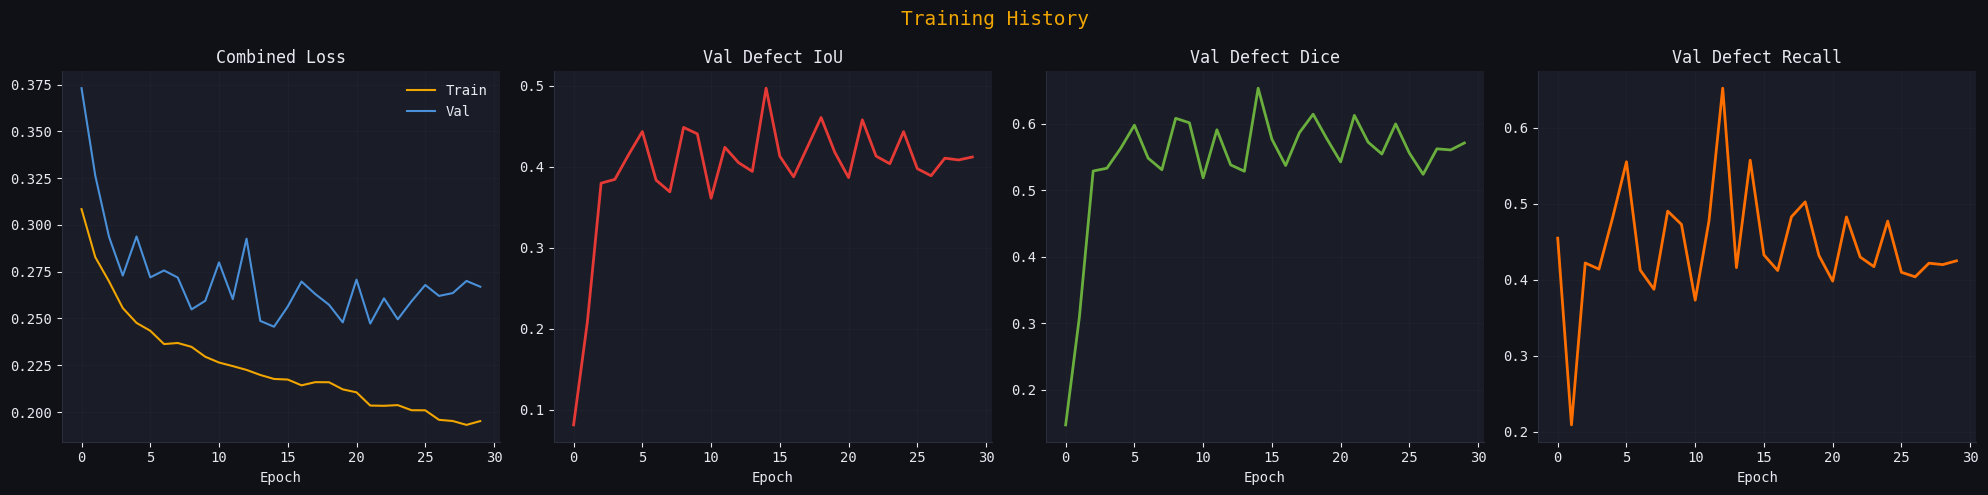

In [20]:
DARK_BG  = "#0F1117"
PANEL_BG = "#1A1D27"
TEXT_COL = "#E8E8F0"
GRID_COL = "#2A2D3A"
ACCENT   = "#F0A500"
 
plt.rcParams.update({
    "figure.facecolor": DARK_BG, "axes.facecolor": PANEL_BG,
    "axes.edgecolor":   GRID_COL, "axes.labelcolor": TEXT_COL,
    "axes.titlecolor":  TEXT_COL, "xtick.color":     TEXT_COL,
    "ytick.color":      TEXT_COL, "text.color":      TEXT_COL,
    "grid.color":       GRID_COL, "font.family":     "monospace",
    "axes.spines.top":  False,    "axes.spines.right": False,
})
 
fig, axes = plt.subplots(1, 4, figsize=(20, 5), facecolor=DARK_BG)
 
axes[0].plot(history["train_loss"], color=ACCENT,    label="Train")
axes[0].plot(history["val_loss"],   color="#4A90D9", label="Val")
axes[0].set_title("Combined Loss",               fontsize=12)
axes[0].set_xlabel("Epoch")
axes[0].legend(framealpha=0, labelcolor=TEXT_COL)
axes[0].grid(alpha=0.3)
 
axes[1].plot(history["val_defect_iou"],    color="#E53935", linewidth=2)
axes[1].set_title("Val Defect IoU",        fontsize=12)
axes[1].set_xlabel("Epoch")
axes[1].grid(alpha=0.3)
 
axes[2].plot(history["val_defect_dice"],   color="#6AAF3D", linewidth=2)
axes[2].set_title("Val Defect Dice",       fontsize=12)
axes[2].set_xlabel("Epoch")
axes[2].grid(alpha=0.3)
 
axes[3].plot(history["val_defect_recall"], color="#FF6F00", linewidth=2)
axes[3].set_title("Val Defect Recall",     fontsize=12)
axes[3].set_xlabel("Epoch")
axes[3].grid(alpha=0.3)
 
plt.suptitle("Training History", fontsize=14, color=ACCENT)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
 

In [21]:
best_model = DilatedSegCNN(in_channels=1, num_classes=NUM_CLASSES).to(device)
best_model.load_state_dict(
    torch.load(os.path.join(OUT_DIR, "checkpoints", "best.pt"), map_location=device)
)
criterion = CombinedLoss().to(device)
 
_, test_metrics = evaluate(best_model, test_loader, criterion)
print_metrics(test_metrics, prefix="TEST SET")


──────────────────────────────────────────────────
 TEST SET Metrics
──────────────────────────────────────────────────
  Class             IoU     Dice   Recall
  --------------------------------------
  Background     0.9979   0.9989   0.9986
  Bark           0.6961   0.8208   0.9295
  Wood           0.9717   0.9856   0.9768
  Knot           0.6493   0.7874   0.9701
  Crack          0.4135   0.5851   0.4657
──────────────────────────────────────────────────
  Mean IoU      : 0.7457
  Defect IoU    : 0.5314
  Defect Dice   : 0.6862
  Defect Recall : 0.7179
──────────────────────────────────────────────────



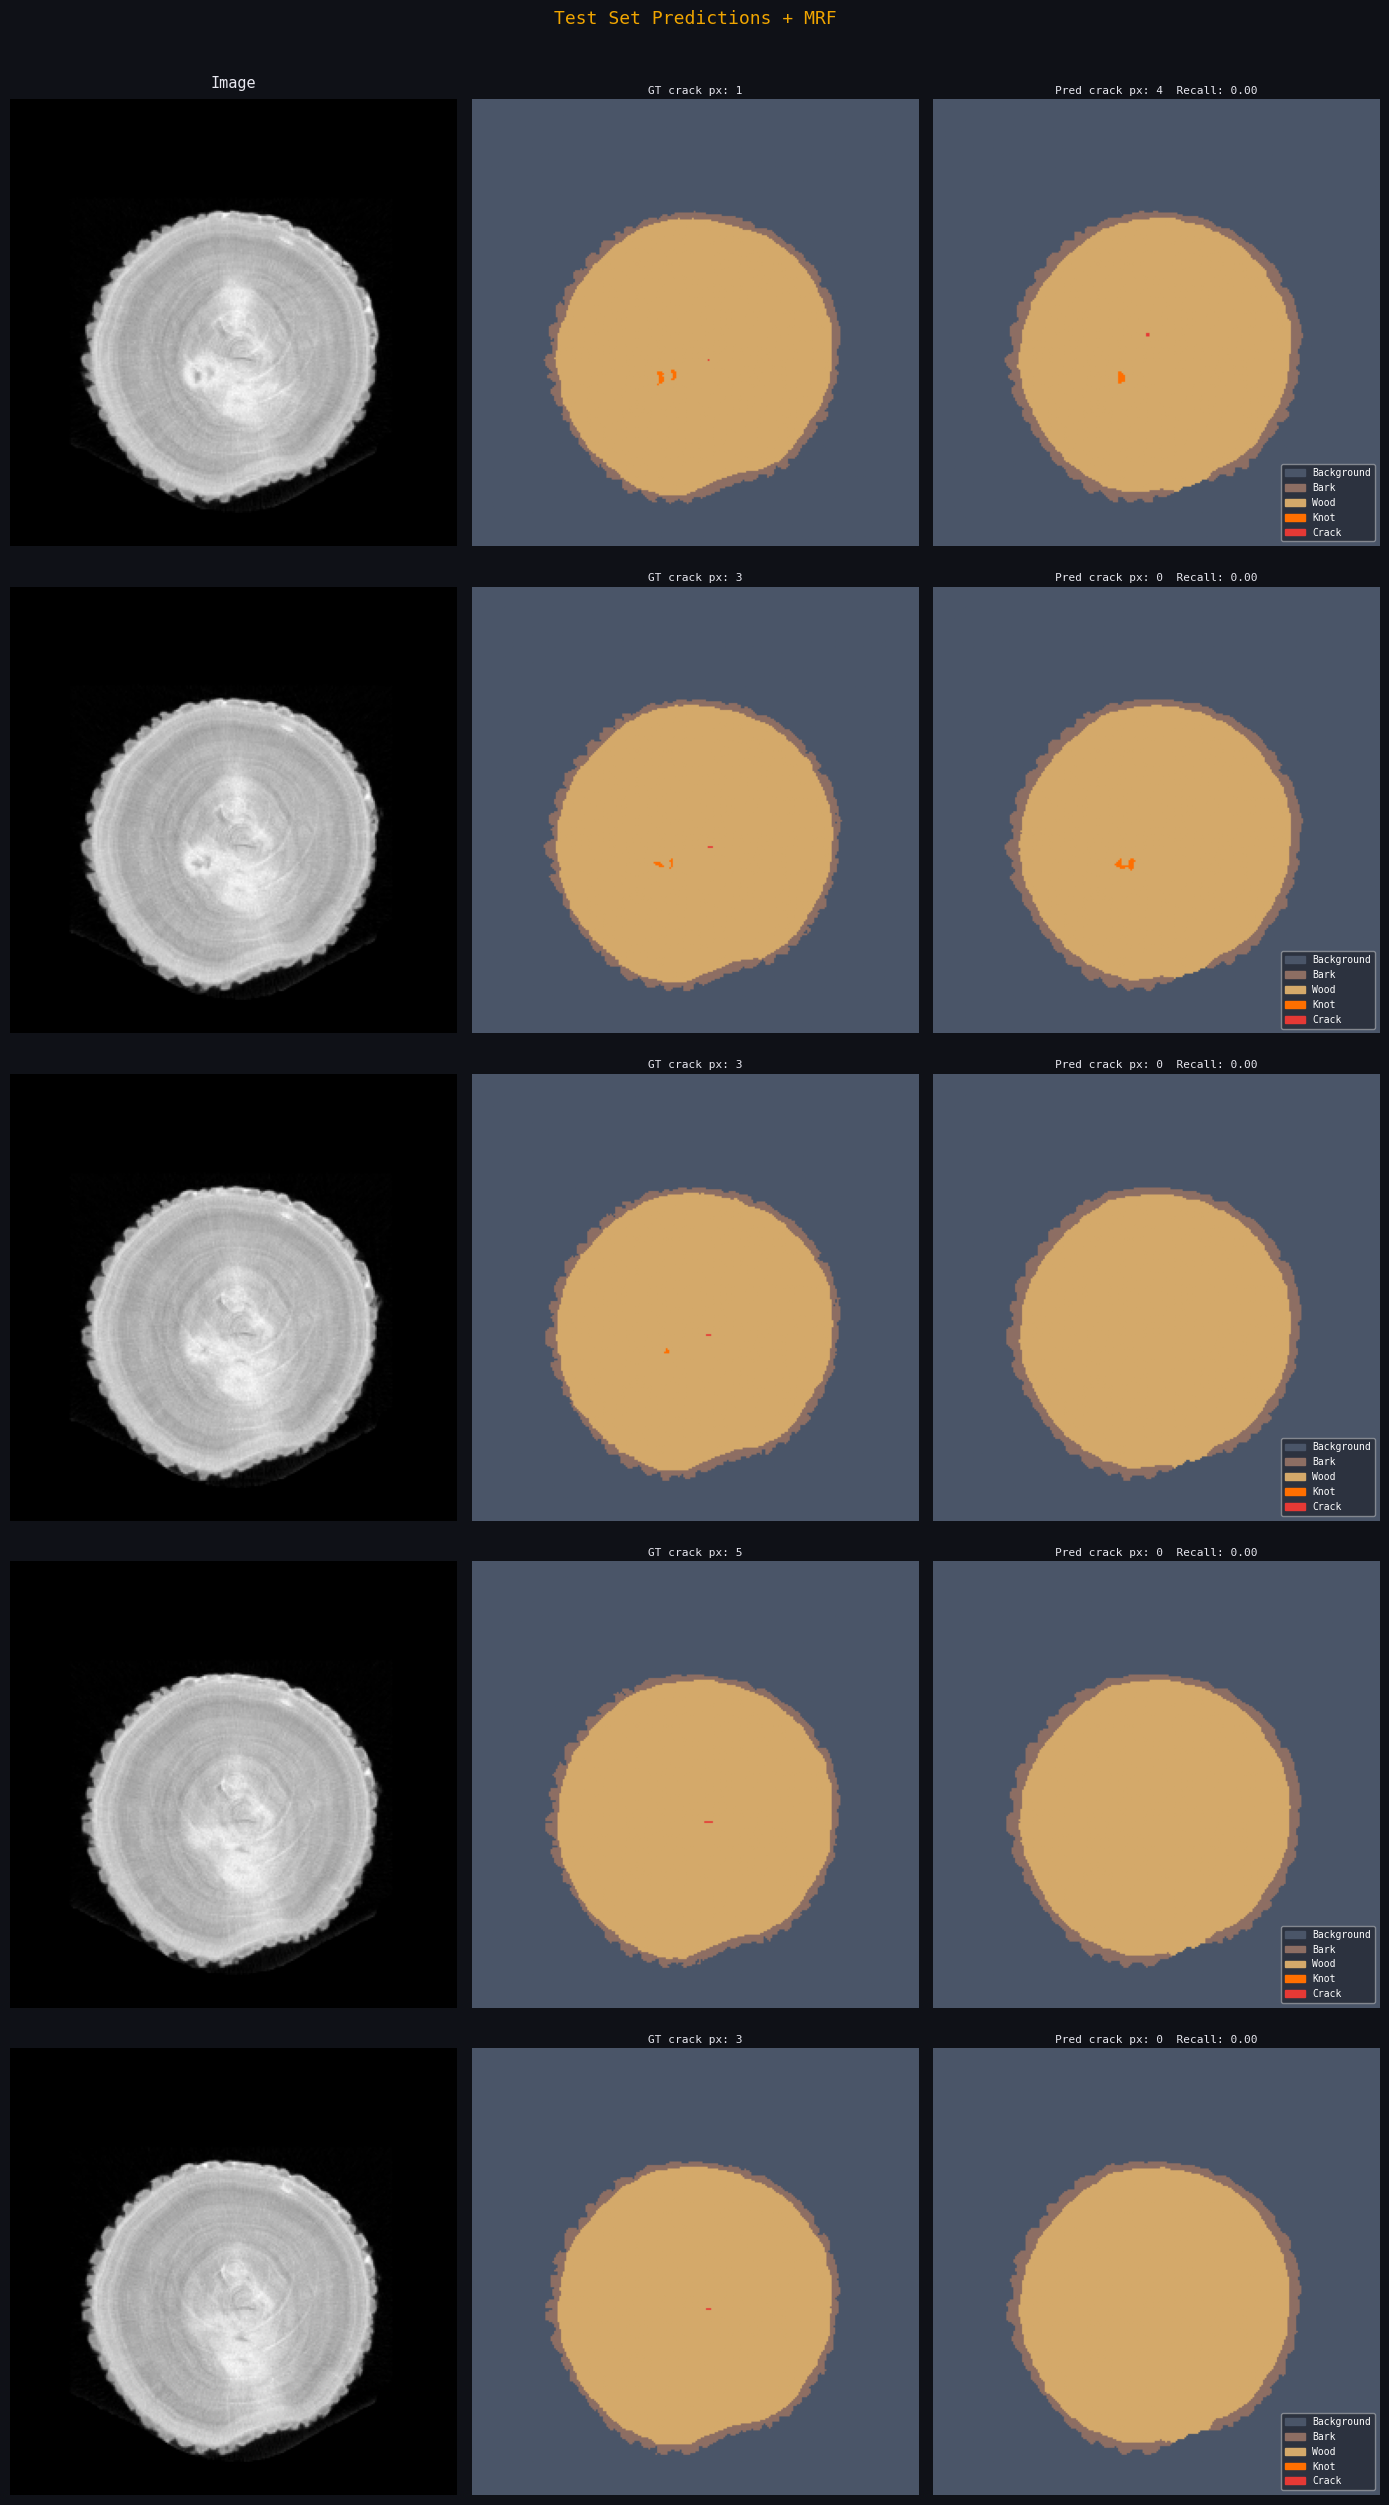

Saved → ../logs/20_trees\test_predictions.png

kmen9 samples in test set: 64


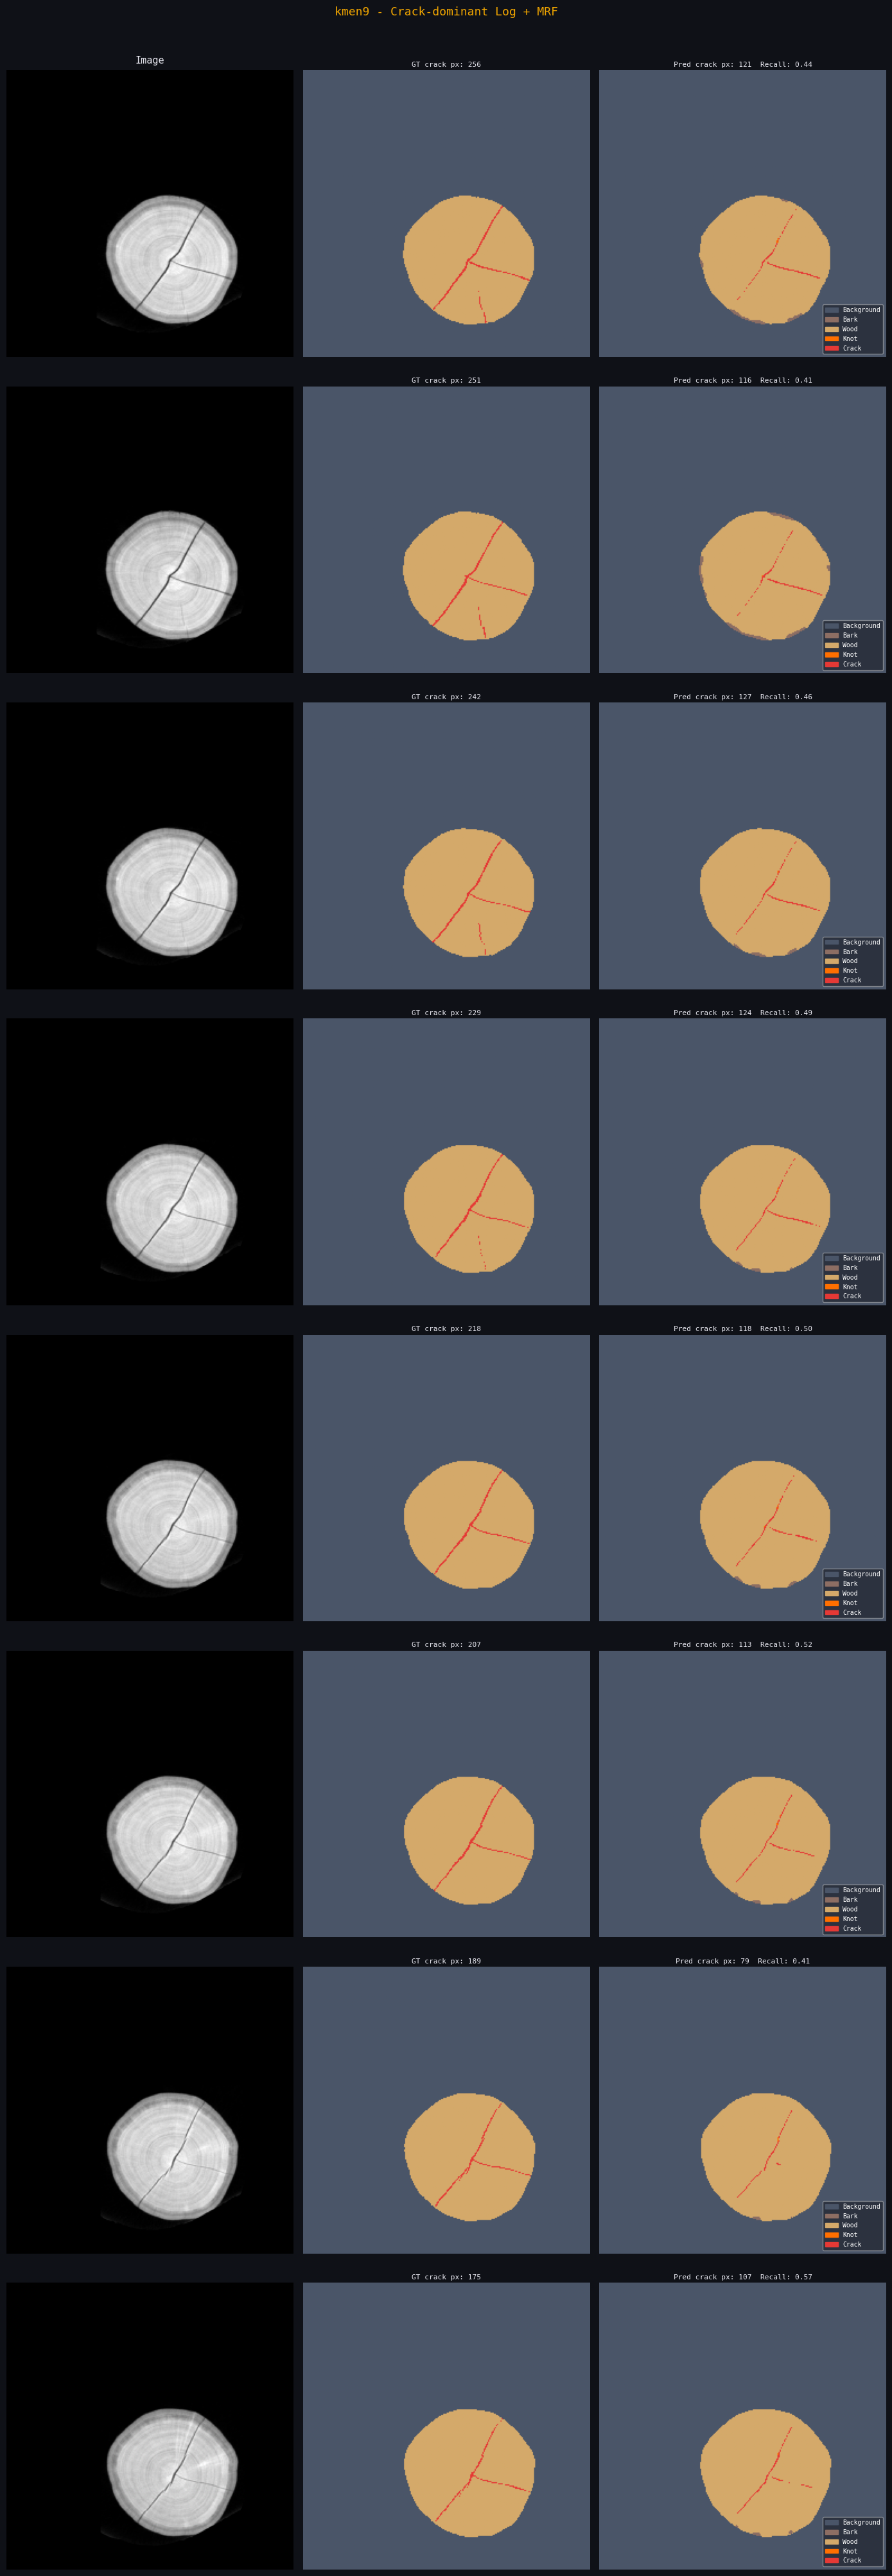

Saved → ../logs/20_trees\test_kmen9_predictions.png
Dub 9 samples in test set: 64


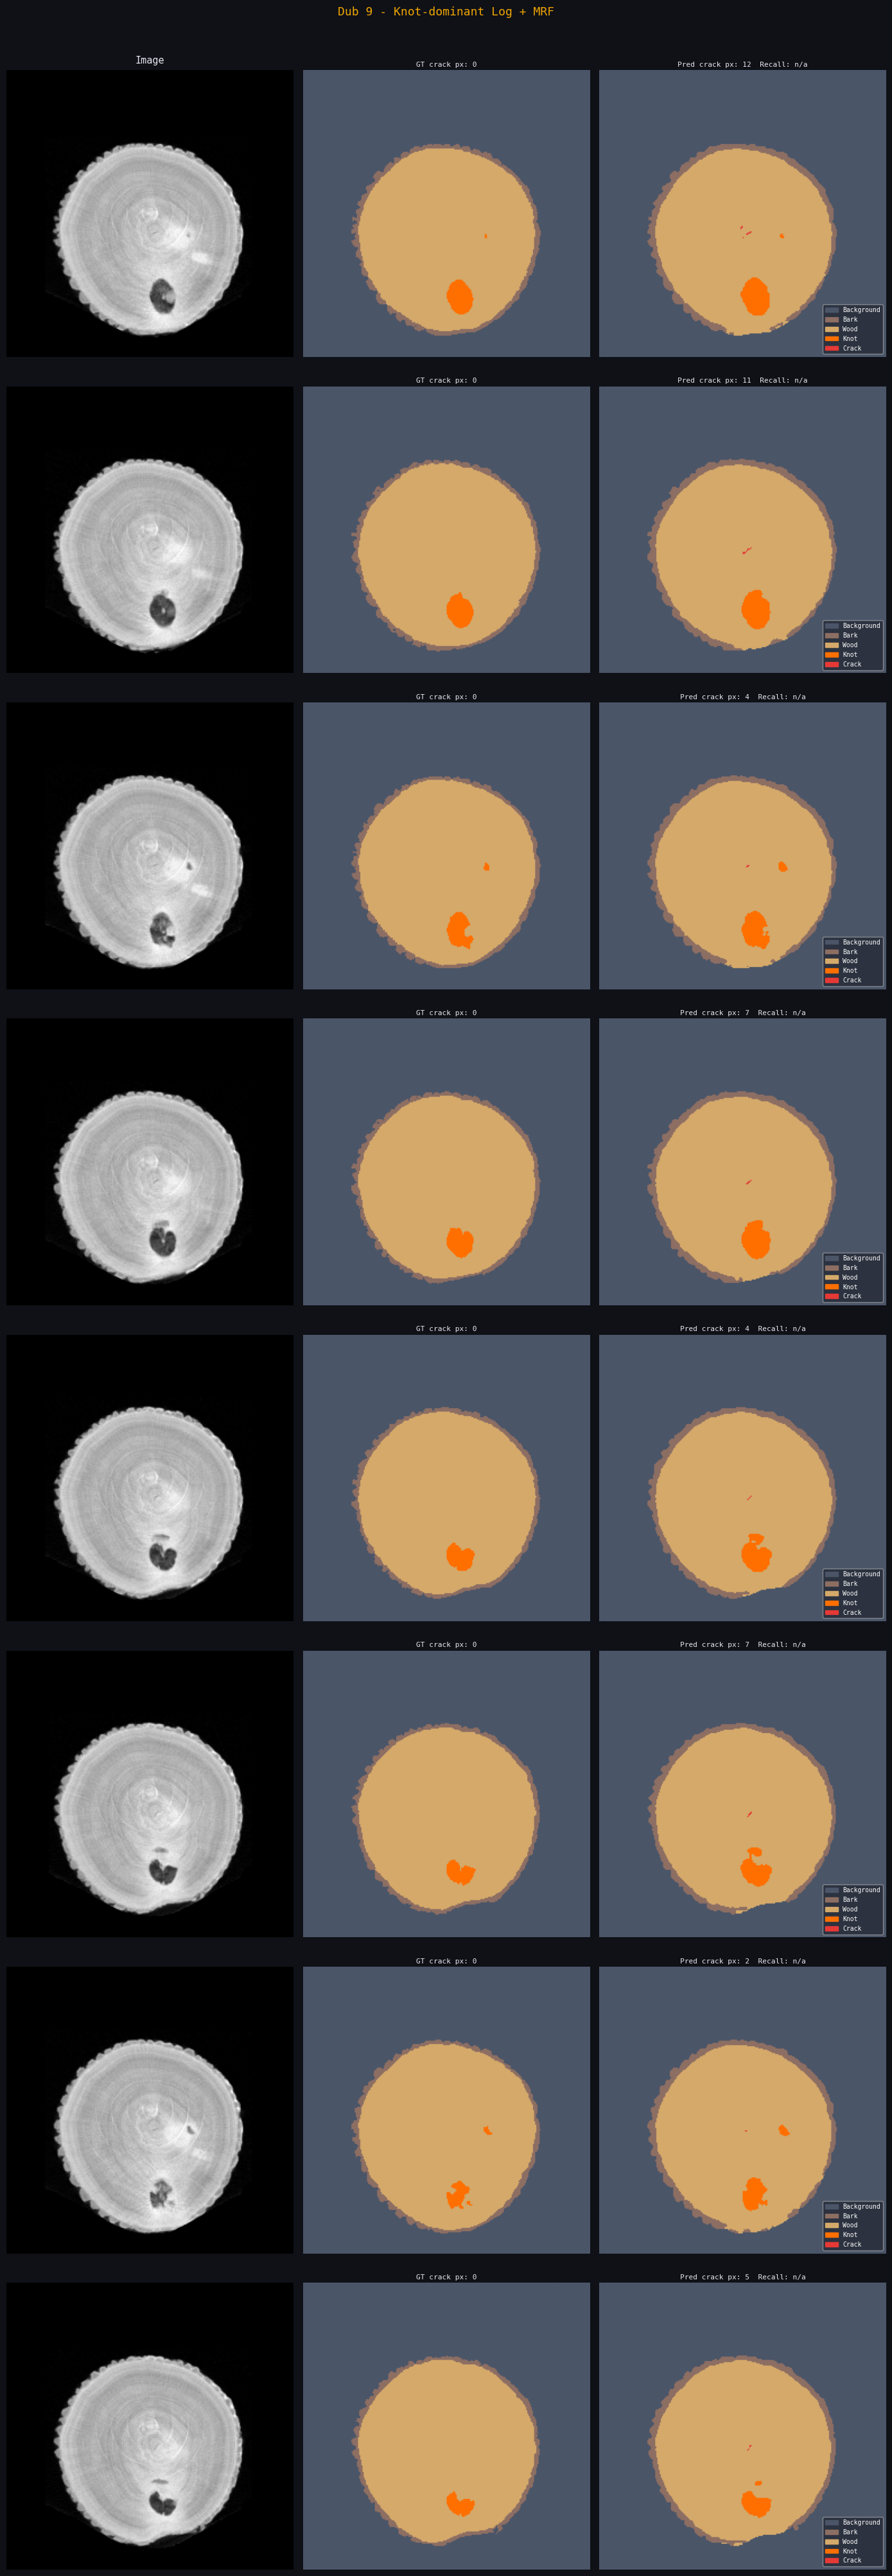

Saved → ../logs/20_trees\test_dub9_predictions.png


In [22]:
# Two sections:
#   A) First N_VIS samples from test set (general)
#   B) kmen9-specific samples (crack-heavy log)
def colorise_mask(mask_np):
    rgb = np.zeros((*mask_np.shape, 3), dtype=np.float32)
    for c, hx in CLASS_COLORS.items():
        r, g, b = [int(hx[i:i+2], 16) / 255 for i in (1, 3, 5)]
        rgb[mask_np == c] = [r, g, b]
    return rgb


def predict_single(model, img_npy, use_mrf=USE_MRF):
    """Run inference on a single cached image, return prediction mask."""
    img = torch.tensor(np.load(img_npy)).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = F.softmax(model(img), dim=1).squeeze(0)   # (C, H, W)
    if use_mrf:
        return mrf_gibbs_sampling(probs).cpu().numpy()
    return torch.argmax(probs, dim=0).cpu().numpy()


def visualise_samples(indices, title, save_name, n_vis=5):
    """
    Visualise a specific set of test indices.
    indices: list of integer indices into cached_test / test_pairs
    """
    indices = indices[:n_vis]
    n       = len(indices)
    if n == 0:
        print(f"No samples found for: {title}")
        return

    fig, axes = plt.subplots(n, 3, figsize=(14, 5 * n), facecolor=DARK_BG)
    if n == 1:
        axes = [axes]   # ensure 2D indexing works for single row

    for col, t in enumerate(["Image", "Ground Truth", "Prediction"]):
        axes[0][col].set_title(t, fontsize=11, pad=8)

    legend_patches = [Patch(color=CLASS_COLORS[c], label=CLASS_NAMES[c])
                      for c in range(NUM_CLASSES)]

    for row, idx in enumerate(indices):
        img_npy, mask_npy = cached_test[idx]
        orig_path         = test_pairs[idx][0]

        img_np  = np.load(img_npy)[0]         # (H, W) — first channel only for display
        mask_np = np.load(mask_npy)
        pred_np = predict_single(best_model, img_npy)

        # count crack pixels for context
        gt_crack   = int((mask_np == 4).sum())
        pred_crack = int((pred_np == 4).sum())
        tp_crack   = int(((mask_np == 4) & (pred_np == 4)).sum())
        recall_str = f"{tp_crack/gt_crack:.2f}" if gt_crack > 0 else "n/a"

        axes[row][0].imshow(img_np, cmap="gray")
        axes[row][0].set_ylabel(os.path.basename(orig_path), fontsize=6,
                                color=TEXT_COL, rotation=0, labelpad=80, va="center")
        axes[row][1].imshow(colorise_mask(mask_np))
        axes[row][1].set_title(f"GT crack px: {gt_crack}", fontsize=8, pad=4)
        axes[row][2].imshow(colorise_mask(pred_np))
        axes[row][2].set_title(f"Pred crack px: {pred_crack}  Recall: {recall_str}",
                               fontsize=8, pad=4)
        axes[row][2].legend(handles=legend_patches, fontsize=7, loc="lower right",
                            framealpha=0.5, facecolor=DARK_BG, labelcolor="white")
        for ax in axes[row]:
            ax.axis("off")

    mrf_tag = " + MRF" if USE_MRF else ""
    plt.suptitle(f"{title}{mrf_tag}", fontsize=13, color=ACCENT, y=1.005)
    plt.tight_layout()
    save_path = os.path.join(OUT_DIR, save_name)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")


# A) General test set samples
general_indices = list(range(min(5, len(cached_test))))
visualise_samples(general_indices, "Test Set Predictions", "test_predictions.png")

# B) kmen9-specific samples (crack-dominant log)
kmen9_indices = [
    i for i, (_, mp) in enumerate(cached_test)
    if "kmen9" in test_pairs[i][0].replace("\\", "/")
]
print(f"\nkmen9 samples in test set: {len(kmen9_indices)}")

# sort by crack pixel count descending — show hardest cases first
kmen9_indices.sort(
    key=lambda i: int((np.load(cached_test[i][1]) == 4).sum()),
    reverse=True
)
visualise_samples(kmen9_indices, "kmen9 - Crack-dominant Log", "test_kmen9_predictions.png", n_vis=8)

# C) Dub9-specific samples (knot-dominant log)
dub9_indices = [
    i for i, (_, mp) in enumerate(cached_test)
    if "Dub 9" in test_pairs[i][0].replace("\\", "/")
    or "Dub9"  in test_pairs[i][0].replace("\\", "/")
]
print(f"Dub 9 samples in test set: {len(dub9_indices)}")

dub9_indices.sort(
    key=lambda i: int((np.load(cached_test[i][1]) == 3).sum()),
    reverse=True
)
visualise_samples(dub9_indices, "Dub 9 - Knot-dominant Log", "test_dub9_predictions.png", n_vis=8)

In [23]:
# Per-log crack recall on test set
best_model.eval()
log_results = defaultdict(lambda: {"tp": 0, "fn": 0})

for i, (img_npy, mask_npy) in enumerate(tqdm(cached_test, desc="Per-log eval")):
    orig_img_path = test_pairs[i][0]
    log_id        = get_log_id(orig_img_path)

    img  = torch.tensor(np.load(img_npy)).unsqueeze(0).to(device)
    mask = torch.tensor(np.load(mask_npy))   # (H, W)

    with torch.no_grad():
        probs = F.softmax(best_model(img), dim=1).squeeze(0)   # (C, H, W)

    if USE_MRF:
        pred = mrf_gibbs_sampling(probs).cpu()
    else:
        pred = torch.argmax(probs, dim=0).cpu()

    crack_cls = 4
    tp = int(((pred == crack_cls) & (mask == crack_cls)).sum())
    fn = int(((pred != crack_cls) & (mask == crack_cls)).sum())

    log_results[log_id]["tp"] += tp
    log_results[log_id]["fn"] += fn

print("\nPer-log Crack Recall:")
for log_id, v in sorted(log_results.items()):
    total  = v["tp"] + v["fn"]
    recall = v["tp"] / total if total > 0 else float("nan")
    print(f"  {log_id:<12} recall={recall:.4f}  (tp={v['tp']:,}  fn={v['fn']:,}  total_crack_px={total:,})")

Per-log eval: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [00:01<00:00, 102.72it/s]



Per-log Crack Recall:
  Dub 9        recall=0.3962  (tp=42  fn=64  total_crack_px=106)
  kmen9        recall=0.4670  (tp=1,897  fn=2,165  total_crack_px=4,062)
